# Fixed exp5 and van Havre Sim 4 target KDEs

Both panels are generated through the same `build_sensitivity_data` interface used by `gendfl_lambda.py`, `gendfl_m.py`, and `gendfl_simulation_num.py`. The left selects `data_synthetic='exp5'`; the right selects `data_synthetic='van-havre'`.

The van Havre mixture parameters copied from the paper are weights $(0.60, 0.39, 0.01)$, means $(6, 10, 20)$, and variances $(1, 1, 0.5)$. Thus its separated high-demand component has probability **0.01**, not 0.10. The separate class `LiteratureGaussianRareEventDGP` uses a 0.10 rare probability from a different rare-event benchmark and is not used here.

Source: [van Havre et al. (2015), Simulation 4](https://pmc.ncbi.nlm.nih.gov/articles/PMC4503697/).

In [25]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

import benchmark_literature_gaussian_rare_event_syn as van_havre_module
from gendfl_lambda import build_parser
from spline_sensitivity_common import build_sensitivity_data, sensitivity_data_tag

# Reload so Run All also works after the DGP implementation changes in an open kernel.
van_havre_module = importlib.reload(van_havre_module)
LiteratureSeparatedRareGaussianDGP = (
    van_havre_module.LiteratureSeparatedRareGaussianDGP
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.dpi': 130,
})

D = 4
FOLD = 1  # Official GenDFL fold: seed=15 with balanced exp5 mixture weights.

OUTPUT_DIR = Path('analysis_outputs/synthetic_target_dgp_comparison')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Generate both targets

The notebook does not create a separate plotting distribution. It plots the raw training and validation observations returned by the GenDFL data interface, so the DGP, seeds, split, and sample count are exactly those used by the numerical experiments.

In [26]:
def interface_args(data_synthetic):
    return build_parser().parse_args([
        '--single-run',
        '--dim', str(D),
        '--fold', str(FOLD),
        '--data_synthetic', data_synthetic,
        '--walmart-path', 'Walmart.csv',
        '--glr-path', 'GLR_lr2.py',
    ])

exp5_args = interface_args('exp5')
van_havre_args = interface_args('van-havre')
exp5_data = build_sensitivity_data(exp5_args)
van_havre_data = build_sensitivity_data(van_havre_args)

exp5_pool = np.vstack([exp5_data.train_raw, exp5_data.validation_raw])
van_havre_pool = np.vstack([van_havre_data.train_raw, van_havre_data.validation_raw])
exp5_y = exp5_pool[:, -1]
van_havre_y = van_havre_pool[:, -1]
van_havre_weights = np.asarray(
    van_havre_data.alignment['mixture_parameters']['raw_component_weights']
)
van_havre_rare_fraction = np.average(
    [
        van_havre_data.alignment['observed_rare_fraction']['train'],
        van_havre_data.alignment['observed_rare_fraction']['validation'],
    ],
    weights=[len(van_havre_data.train_raw), len(van_havre_data.validation_raw)],
)

assert sensitivity_data_tag(exp5_args) == 'iid_exp5'
assert sensitivity_data_tag(van_havre_args) == 'van_havre_sim4'
assert np.allclose(van_havre_weights, [0.60, 0.39, 0.01])

# Replay the exact GenDFL Van Havre training pool only to recover its full
# three-component labels; demands and contexts must match the interface data.
van_config = van_havre_data.alignment['mixture_parameters']
van_havre_dgp = LiteratureSeparatedRareGaussianDGP(
    context_dim=D,
    seed=van_havre_data.alignment['parameter_random_state'],
    demand_scale=van_config['demand_scale'],
    demand_shift=van_config['demand_shift'],
    context_amplitude=van_config['context_amplitude'],
)
replay_x, replay_y, replay_component = van_havre_dgp.sample(
    van_havre_data.alignment['num_samples'],
    seed=van_havre_data.alignment['train_sample_random_state'],
    return_component_index=True,
)
replay_indices = np.arange(len(replay_x))
train_indices, validation_indices = train_test_split(
    replay_indices, test_size=0.1, random_state=42
)
display_indices = np.concatenate([train_indices, validation_indices])
van_havre_component = replay_component[display_indices]
replayed_pool = np.column_stack((replay_x, replay_y[:, 0]))[display_indices]
np.testing.assert_allclose(replayed_pool, van_havre_pool, rtol=0.0, atol=0.0)

summary = pd.DataFrame([
    {
        'generator': 'Corrected fixed exp5 DGP',
        'n': len(exp5_y),
        'mean': exp5_y.mean(),
        'std': exp5_y.std(),
        'minimum': exp5_y.min(),
        'median': np.median(exp5_y),
        'p99': np.quantile(exp5_y, 0.99),
        'maximum': exp5_y.max(),
        'rare_probability': np.nan,
    },
    {
        'generator': 'van Havre Sim 4 conditional extension',
        'n': len(van_havre_y),
        'mean': van_havre_y.mean(),
        'std': van_havre_y.std(),
        'minimum': van_havre_y.min(),
        'median': np.median(van_havre_y),
        'p99': np.quantile(van_havre_y, 0.99),
        'maximum': van_havre_y.max(),
        'rare_probability': van_havre_rare_fraction,
    },
])
summary.round(3)

,generator,n,mean,std,minimum,median,p99,maximum,rare_probability
0,Corrected fixed exp5 DGP,12870,95.526001,46.255001,6.317,77.903000,177.751007,195.574005,NaN
1,van Havre Sim 4 conditional extension,12870,185.039993,52.765999,56.875,175.102005,306.313995,491.966003,0.01


## One-row KDE comparison

The panels use separate horizontal and vertical scales because the two DGPs use different target units. On the right, the three filled KDE contributions are jointly normalized, so their areas retain the published 0.60, 0.39, and 0.01 mixture proportions.

van Havre Sim 4 conditional extension target quantile 435.10


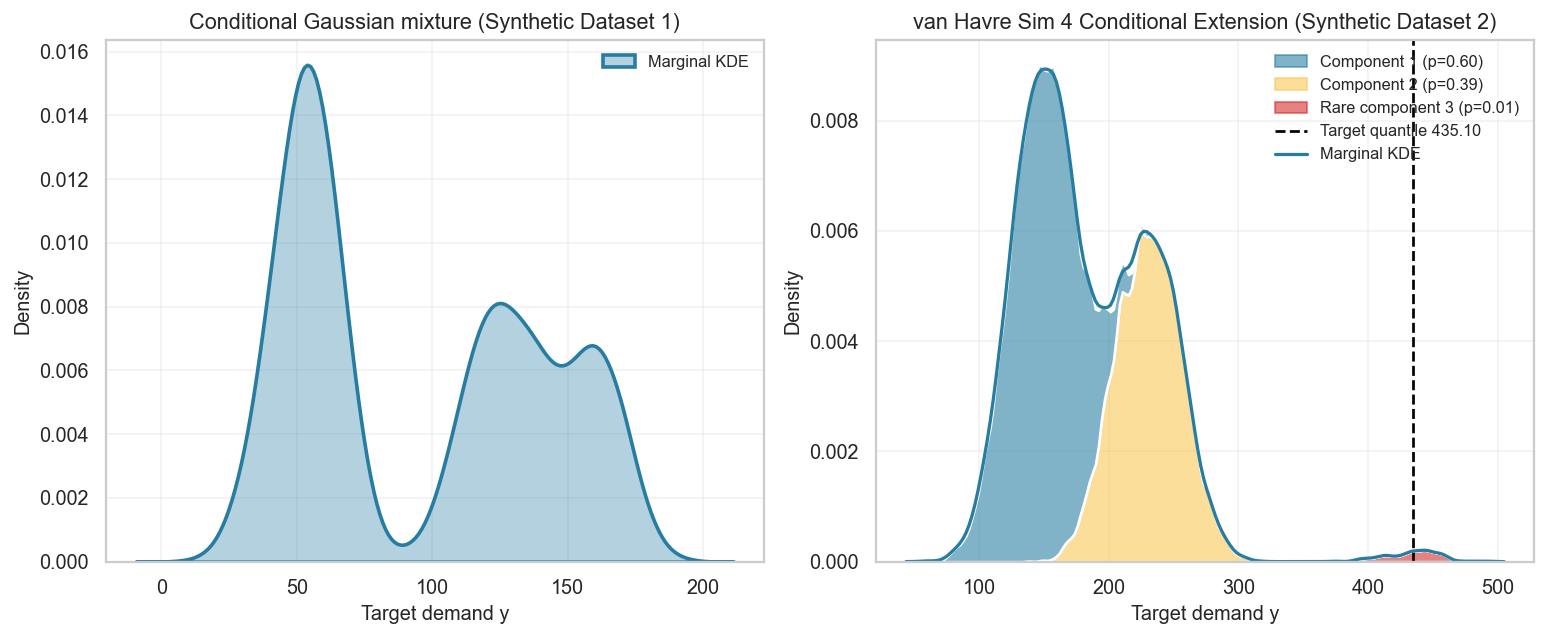

Saved figure to /Users/seinzhou/Desktop/wsc_newexp/analysis_outputs/synthetic_target_dgp_comparison/fixed_exp5_vs_van_havre_sim4_kde.png


In [27]:
figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

sns.kdeplot(
    x=exp5_y, fill=True, color='#277DA1', alpha=0.35, linewidth=2.0,
    bw_adjust=0.75, ax=axes[0], label='Marginal KDE',
)
axes[0].set_title('Conditional Gaussian mixture (Synthetic Dataset 1)')
axes[0].set_xlabel('Target demand y')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=False, loc='upper right')
target_quantile = 199/(199+1)
import torch
target_quantile = torch.kthvalue(torch.tensor(van_havre_y), int(target_quantile * len(van_havre_y))).values.item()
component_names = np.asarray([
    'Component 1 (p=0.60)',
    'Component 2 (p=0.39)',
    'Rare component 3 (p=0.01)',
])
van_plot = pd.DataFrame({
    'Target demand y': van_havre_y,
    'Component': component_names[van_havre_component],
})
component_hue_order = component_names.tolist()
component_palette = ['#277DA1', '#F9C74F', '#D62828']
sns.kdeplot(
    data=van_plot, x='Target demand y', hue='Component',
    hue_order=component_hue_order, palette=component_palette,
    multiple='stack', common_norm=True, fill=True, alpha=0.58,
    linewidth=1.4, bw_adjust=0.55, ax=axes[1],
)
print(f'van Havre Sim 4 conditional extension target quantile {target_quantile:.2f}')
target_quantile_label = f'Target quantile {target_quantile:.2f}'
axes[1].axvline(
    x=target_quantile, color='black', linestyle='--', linewidth=1.5,
    label=target_quantile_label,
)

sns.kdeplot(
    x=van_havre_y, color='#277DA1', linewidth=1.8, bw_adjust=0.55,
    ax=axes[1], label='Marginal KDE',
)
axes[1].set_title('van Havre Sim 4 Conditional Extension (Synthetic Dataset 2)')
axes[1].set_xlabel('Target demand y')
axes[1].set_ylabel('Density')
component_order = component_hue_order + [target_quantile_label, 'Marginal KDE']
component_handles = [
    Patch(facecolor=color, edgecolor=color, alpha=0.58, label=label)
    for label, color in zip(component_hue_order, component_palette)
]
component_handles.extend([
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.5, label=target_quantile_label),
    Line2D([0], [0], color='#277DA1', linewidth=1.8, label='Marginal KDE'),
])
axes[1].legend(
    handles=component_handles, labels=component_order,
    frameon=False, loc='upper right',
)

for axis in axes:
    axis.grid(True, alpha=0.22)


figure.tight_layout()
figure_path = OUTPUT_DIR / 'fixed_exp5_vs_van_havre_sim4_kde.png'
figure.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure to {figure_path.resolve()}')

## What is copied and what is extended

- **Copied from van Havre Sim 4:** weights $(0.60, 0.39, 0.01)$, means $(6,10,20)$, and variances $(1,1,0.5)$.
- **Project extensions:** positive affine demand scaling and a bounded common shift $25\tanh(v^T x)$ so that the target is contextual while all three component weights and their separation remain unchanged.
- **Not used in this notebook:** the separate 10% `LiteratureGaussianRareEventDGP`.